In [1]:
import numpy as np
import pandas as pd

np.random.seed(42)

n_samples = 5000

time = np.arange(n_samples)

# Base signals
blast_temp = 1100 + 20*np.sin(time/200) + np.random.normal(0, 5, n_samples)
blast_pressure = 2.5 + 0.1*np.sin(time/150) + np.random.normal(0, 0.05, n_samples)
o2_percent = 21 + np.random.normal(0, 0.3, n_samples)
pci_rate = 150 + 10*np.sin(time/300) + np.random.normal(0, 3, n_samples)

topgas_co = 22 + np.random.normal(0, 1, n_samples)
topgas_co2 = 18 + np.random.normal(0, 1, n_samples)

tuyere_temp = 1800 + 30*np.sin(time/100) + np.random.normal(0, 10, n_samples)
cooling_deltaT = 15 + np.random.normal(0, 1, n_samples)
shell_temp = 300 + np.random.normal(0, 5, n_samples)
vibration = 2 + np.random.normal(0, 0.2, n_samples)

# Simulate degradation
degradation = np.linspace(0, 200, n_samples)
shell_temp += degradation * 0.05
tuyere_temp += degradation * 0.1
vibration += degradation * 0.005

# RUL (decreasing)
RUL = np.maximum(200 - degradation, 0)

# Failure Types
failure_type = np.zeros(n_samples)

# Inject failures
for i in range(1000, 5000, 1000):
    failure_type[i:i+50] = 1  # Tuyere failure
    tuyere_temp[i:i+50] += 200

for i in range(1500, 5000, 1500):
    failure_type[i:i+50] = 2  # Cooling failure
    cooling_deltaT[i:i+50] += 10
    shell_temp[i:i+50] += 50

# Anomalies
anomaly = np.zeros(n_samples)
anomaly_idx = np.random.choice(n_samples, size=200, replace=False)

blast_temp[anomaly_idx] += np.random.normal(100, 20, len(anomaly_idx))
vibration[anomaly_idx] += np.random.normal(2, 0.5, len(anomaly_idx))
anomaly[anomaly_idx] = 1

#Create DataFrame
df = pd.DataFrame({
    "Time": time,
    "BlastTemp": blast_temp,
    "BlastPressure": blast_pressure,
    "O2Percent": o2_percent,
    "PCI_Rate": pci_rate,
    "TopGas_CO": topgas_co,
    "TopGas_CO2": topgas_co2,
    "TuyereTemp": tuyere_temp,
    "CoolingWater_DeltaT": cooling_deltaT,
    "ShellTemp": shell_temp,
    "Vibration": vibration,
    "RUL": RUL,
    "FailureType": failure_type,
    "Anomaly": anomaly
})

print(df.head())

# Save dataset
df.to_csv("blast_furnace_synthetic_data.csv", index=False)

   Time    BlastTemp  BlastPressure  O2Percent    PCI_Rate  TopGas_CO  \
0     0  1102.483571       2.478812  20.796452  149.569730  22.348286   
1     1  1099.408678       2.477996  20.908350  149.935366  22.283324   
2     2  1103.438439       2.411551  20.820786  150.259551  21.063480   
3     3  1107.915138       2.485495  21.033125  152.940583  22.579584   
4     4  1099.229206       2.539308  21.359154  147.891677  20.509917   

   TopGas_CO2   TuyereTemp  CoolingWater_DeltaT   ShellTemp  Vibration  \
0   18.170874  1780.194280            15.914098  297.640712   2.209956   
1   18.012255  1789.754139            16.624487  305.065513   1.844093   
2   17.568845  1794.737678            15.345517  299.013067   2.240281   
3   17.997473  1802.408557            14.744879  300.458848   1.988375   
4   18.490842  1811.457306            13.933275  303.594955   2.172031   

          RUL  FailureType  Anomaly  
0  200.000000          0.0      0.0  
1  199.959992          0.0      0.0  
2 

In [2]:
df = df.drop(columns=['FailureType','Anomaly'],axis=1)

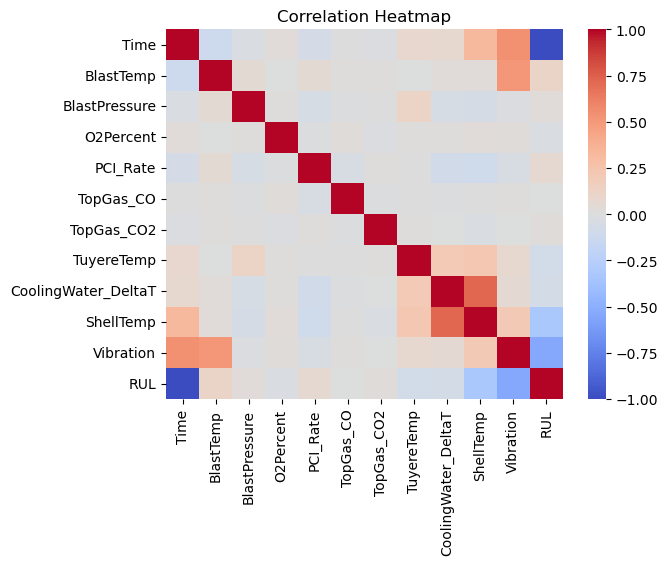

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
corr = df.corr()
sns.heatmap(corr, annot=False, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [4]:
train=df.copy()

In [7]:
def remove_outliers_iqr(df):
    df_clean = df.copy()
    
    for col in df_clean.select_dtypes(include=['int64', 'float64']).columns:
        
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        df_clean = df_clean[
            (df_clean[col] >= lower_bound) & 
            (df_clean[col] <= upper_bound)
        ]
    
    return df_clean

In [8]:
ctrain = remove_outliers_iqr(train)

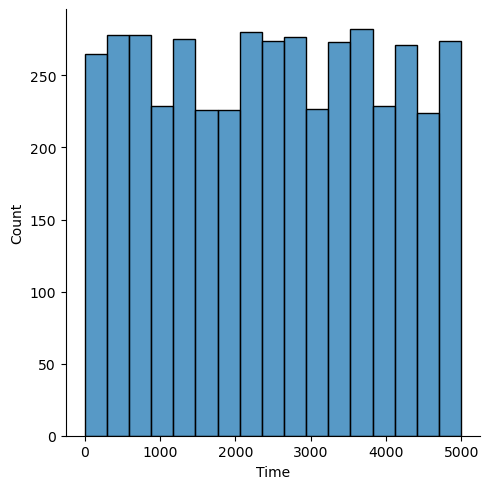

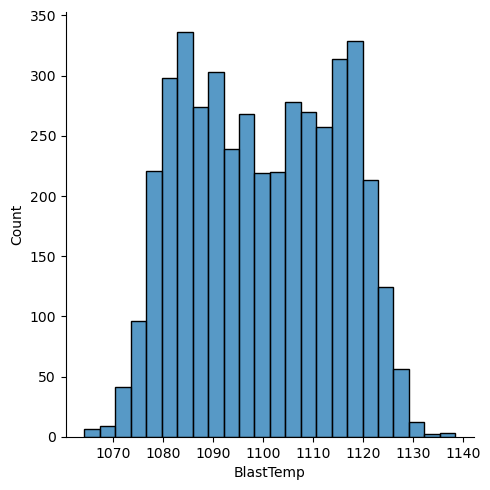

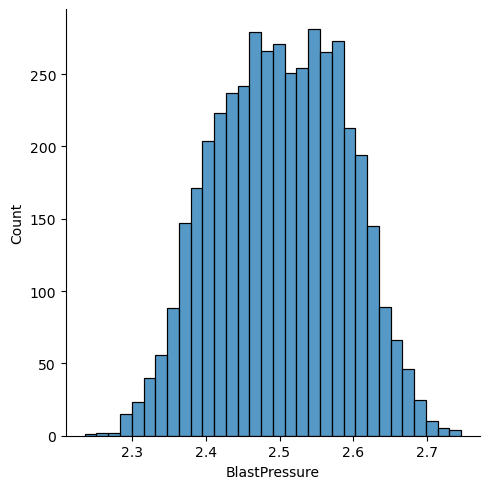

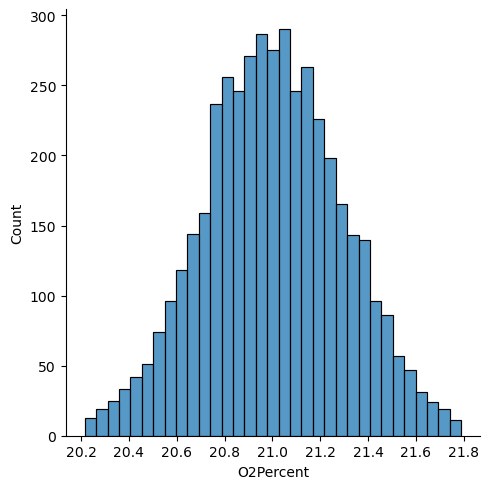

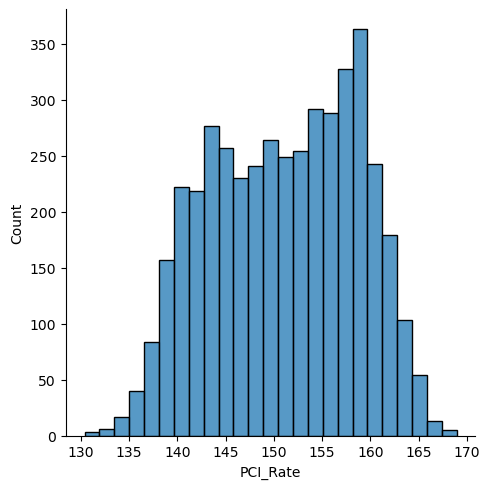

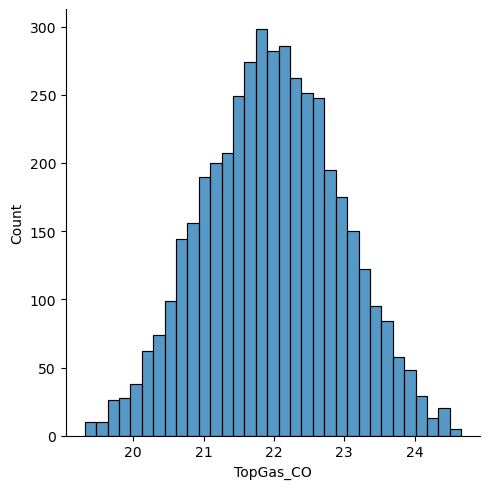

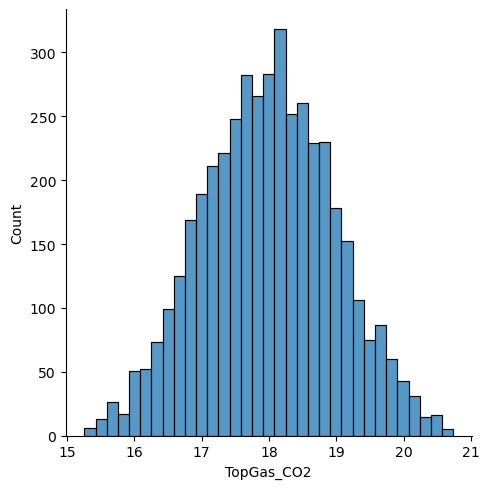

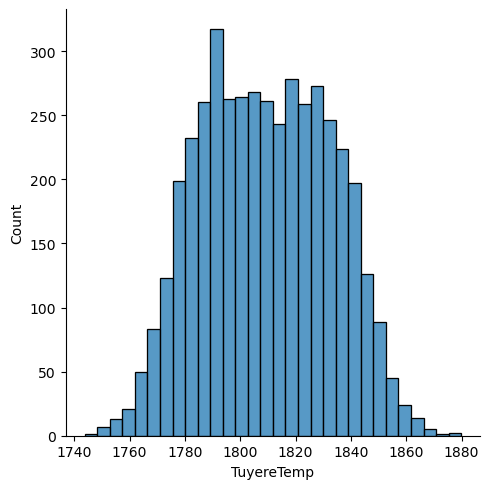

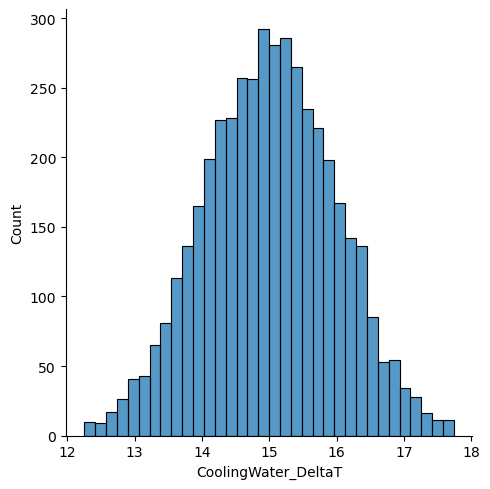

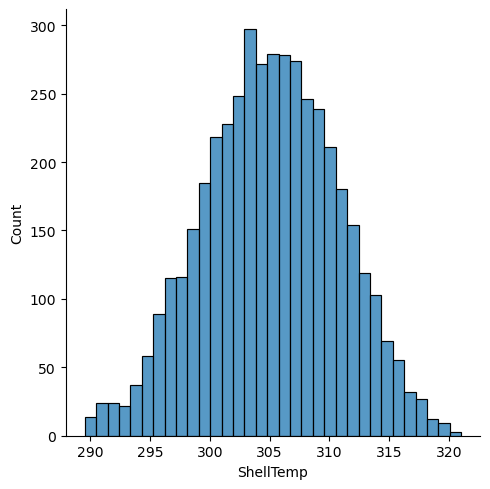

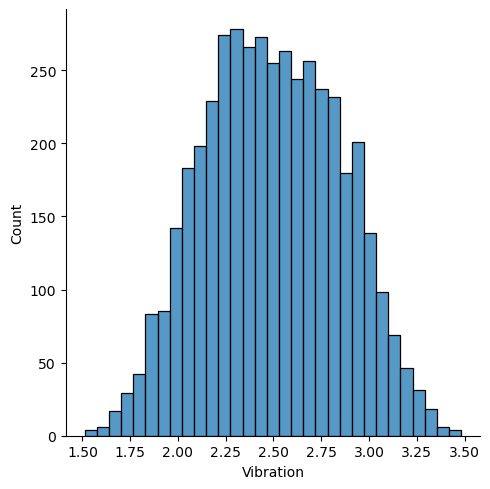

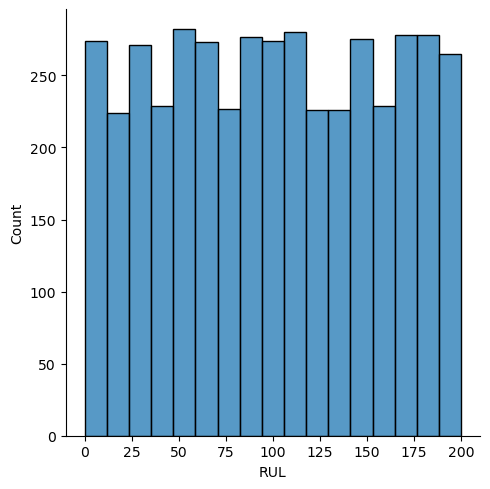

In [9]:
for i in ctrain.columns:
  sns.displot(ctrain[i])
  plt.show()

In [11]:
windows = [5, 10, 20]


df = ctrain.sort_values("Time").reset_index(drop=True)

sensor_cols = [
    "BlastTemp", "BlastPressure", "O2Percent", "PCI_Rate",
    "TopGas_CO", "TopGas_CO2", "TuyereTemp",
    "CoolingWater_DeltaT", "ShellTemp", "Vibration"
]

for w in windows:
    for col in sensor_cols:
        

        df[f"{col}_rolling_mean_{w}"] = df[col].rolling(window=w, min_periods=1).mean()
        

        df[f"{col}_rolling_diff_{w}"] = df[col].diff().rolling(window=w, min_periods=1).mean()


        df[f"{col}_rolling_std_{w}"] = df[col].rolling(window=w, min_periods=1).std()

In [12]:
df = df.dropna()

In [13]:
x = df.drop(columns=["RUL"])
y = df["RUL"]
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size= 0.2, random_state=42)  



In [14]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error
class AccureacyScore:
  def __init__(self, y_true, y_pred):
    self.y_true = y_true
    self.y_pred = y_pred

  def rmse(self):
    return np.sqrt(mean_squared_error(self.y_true, self.y_pred))
  def mse(self):
    return mean_squared_error(self.y_true, self.y_pred)
  def r2_score(self):
    return r2_score(self.y_true, self.y_pred)
  def mae(self):
    return mean_absolute_error(self.y_true, self.y_pred)
  def mape(self):
    return mean_absolute_percentage_error(self.y_true, self.y_pred)
  def nasa_phm_score(self):
    score = 0
    for true, pred in zip(self.y_true, self.y_pred):
        error = pred - true
        if error < 0:
            score += np.exp(-error/13) - 1
        else:
            score += np.exp(error/10) - 1
    return score



In [12]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

model.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [15]:
y_pred = model.predict(x_test)
eveluate = AccureacyScore(y_test, y_pred)
print("Root Mean Squared Error:", eveluate.rmse())
print("Mean Squared Error:", eveluate.mse())
print("R2_score:", eveluate.r2_score())
print("Mean Absolute Error:", eveluate.mae())
print("Mean Absolute Percentage Error:", eveluate.mape())
print("NASA_PHM Score:", eveluate.nasa_phm_score())

Root Mean Squared Error: 8.445878530759163e-14
Mean Squared Error: 7.133286415633856e-27
R2_score: 1.0
Mean Absolute Error: 7.2300555823243e-14
Mean Absolute Percentage Error: 1.1662870159453331
NASA_PHM Score: 5.735412145213559e-12


In [15]:
from sklearn.ensemble import RandomForestRegressor
model_1 = RandomForestRegressor(
    n_estimators=500,
    criterion='squared_error',
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    min_weight_fraction_leaf=0.0,
    max_features=1.0,
    max_leaf_nodes=None,
    min_impurity_decrease=0.0
)
model_1.fit(x_train,y_train)

,n_estimators,500
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [16]:
import joblib
joblib.dump(model_1,'rul_model.pkl')

['rul_model.pkl']

In [17]:
y_pred = model_1.predict(x_test)
eveluate = AccureacyScore(y_test, y_pred)
print("Root Mean Squared Error:", eveluate.rmse())
print("Mean Squared Error:", eveluate.mse())
print("R2_score:", eveluate.r2_score())
print("Mean Absolute Error:", eveluate.mae())
print("Mean Absolute Percentage Error:", eveluate.mape())
print("NASA_PHM Score:", eveluate.nasa_phm_score())

Root Mean Squared Error: 0.0637584259732008
Mean Squared Error: 0.004065136882580127
R2_score: 0.9999987995211794
Mean Absolute Error: 0.03915425454111325
Mean Absolute Percentage Error: 2277902316855.691
NASA_PHM Score: 3.1559402327372137
